# Example Alpha Analysis Using Orderbook Features

This notebook demonstrates how to build and analyze alpha signals using orderbook microstructure data.

## Concepts

An **alpha** is a strategy or signal that attempts to predict or exploit market movements:
- **Imbalance Alpha**: Detects when one side of the book is significantly larger (indicates strength)
- **Spread Alpha**: Analyzes bid-ask spread as a proxy for execution costs and volatility

## Workflow

1. **Load** market events from cached parquet data
2. **Compute** orderbook features (imbalance, spread, depth)
3. **Analyze** features to generate trading signals
4. **Evaluate** signal quality and market correlations

## Setup: Initialize Data Pipeline

In [1]:

import sys
from pathlib import Path

# Add parent directory to path to import local modules
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import logging
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from backtester import BacktestRunner
from config import STREAM_FEEDS_DIR
from utils import setup_application_logging
from visualization import (
    plot_imbalance,
    plot_market_timeline,
    plot_orderbook_depth,
    plot_spread_timeseries,
)

setup_application_logging()
logger = logging.getLogger(__name__)

print("✓ Imports complete")

✓ Imports complete


## Step 1: Load Market Data and Compute Features

The `BacktestRunner` loads parquet files containing market events and computes orderbook features.

**Important Features:**
- `imbalance_1`: Bid vs ask imbalance at best level = (bid_size₁ - ask_size₁) / (bid_size₁ + ask_size₁)
- `imbalance_5`: Same calculation using top 5 levels
- `spread`: Difference between best ask and best bid
- `bid_depth_1` / `ask_depth_1`: Total size at best level
- `mid_price`: Average of best bid and ask

In [3]:
storage_path = STREAM_FEEDS_DIR

if not storage_path.exists():
    print(f"❌ Storage path not found: {storage_path}")
    print("Ensure stream data has been collected first.")
else:
    runner = BacktestRunner(storage_path=storage_path)
    print(f"✓ BacktestRunner initialized with {storage_path}")
    print("✓ Reloaded backtester/feature modules")

2026-03-02 12:34:36 - backtester.runner - INFO - Initialized BacktestRunner with storage path: /Users/rahulthaker/Documents/coding/python/onlyPositiveAlpha/data/cached/stream_feeds
2026-03-02 12:34:36 - backtester.runner - INFO - Feature cache directory: /Users/rahulthaker/Documents/coding/python/onlyPositiveAlpha/data/cached/feature_cache


✓ BacktestRunner initialized with /Users/rahulthaker/Documents/coding/python/onlyPositiveAlpha/data/cached/stream_feeds
✓ Reloaded backtester/feature modules


In [4]:
# Define time window for analysis
end = datetime.now(tz=UTC)
start = end - pd.Timedelta(days=1)

print(f"Analysis window: {start.isoformat()} to {end.isoformat()}")

# Load market events and compute features
# NOTE: Using limit_files=None to load ALL parquet files for comprehensive alpha backtesting
print("\nLoading market events...")
market_events = runner.load_market_events(start=start, end=end, limit_files=5)

if market_events.empty:
    print("❌ No market events found")
else:
    print(f"✓ Loaded {len(market_events)} events")
    print(f"Event types:\n{market_events['event_type'].value_counts()}")

Analysis window: 2026-03-01T04:34:36.156063+00:00 to 2026-03-02T04:34:36.156063+00:00

Loading market events...


2026-03-02 12:34:39 - backtester.runner - INFO - Loaded 349573 market events


✓ Loaded 349573 events
Event types:
event_type
price_change        285699
best_bid_ask         28294
book                 23750
last_trade_price     11778
new_market              39
tick_size_change         8
market_resolved          5
Name: count, dtype: int64


In [5]:
# Compute orderbook features with caching (much faster on subsequent runs!)
print("\nComputing orderbook features...")
features = runner.compute_orderbook_features_cached(market_events, use_cache=True)

print(f"✓ Computed {len(features)} feature vectors")
print(f"\nColumns: {list(features.columns)}")

2026-03-02 12:34:39 - backtester.runner - INFO - Computing features (no cache found)...



Computing orderbook features...


2026-03-02 12:34:50 - backtester.runner - INFO - Computed orderbook features for 594188 events (23750 book, 285699 price_change)
2026-03-02 12:34:51 - backtester.runner - INFO - Saved 594188 features to cache: /Users/rahulthaker/Documents/coding/python/onlyPositiveAlpha/data/cached/feature_cache/features_5b6354580f5d50e6.parquet


✓ Computed 594188 feature vectors

Columns: ['market_id', 'token_id', 'spread', 'spread_bps', 'mid_price', 'bid_depth_1', 'ask_depth_1', 'bid_depth_5', 'ask_depth_5', 'imbalance_1', 'imbalance_5', 'bid_ask_ratio']


## Step 2: Explore Feature Statistics

Understanding your features is crucial before building alphas.

In [6]:
# Quick sanity checks for prior cells
required_vars = ["features", "market_events"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    error_message = (
        f"Missing required variables: {missing}. Run earlier cells first to build data."
    )
    raise RuntimeError(error_message)

print("✓ Visualization module imported")
print(f"features rows: {len(features)}")
print(f"market events rows: {len(market_events)}")

✓ Visualization module imported
features rows: 594188
market events rows: 349573


In [7]:
sample_market_id = (
    features["market_id"].dropna().iloc[0]
    if "market_id" in features.columns and not features.empty
    else None
)

plot_features = features.copy()
plot_market_events = market_events.copy()
if sample_market_id is not None:
    plot_features = plot_features[plot_features["market_id"] == sample_market_id].copy()
    plot_market_events = plot_market_events[
        plot_market_events["market_id"] == sample_market_id
    ].copy()

sample_token_id = (
    plot_features["token_id"].dropna().iloc[0]
    if "token_id" in plot_features.columns and not plot_features.empty
    else None
)
if sample_token_id is not None:
    plot_features = plot_features[plot_features["token_id"] == sample_token_id].copy()


In [ ]:
# Cut visualizations at meaningful endpoint:
# 1) hard resolution timestamp (if present)
# 2) last timestamp where core features still change (avoids flat stale tails)
FEATURE_CHANGE_TOLERANCE = 1e-12  # Minimum absolute change to detect feature updates

resolution_ts = None
resolution_events = plot_market_events[
    plot_market_events["event_type"] == "market_resolved"
]
if not resolution_events.empty:
    resolution_ts = resolution_events.index.min()

change_cols = [
    col for col in ["mid_price", "spread", "imbalance_1"]
    if col in plot_features.columns
]
last_change_ts = None
if change_cols and not plot_features.empty:
    changes = pd.Series(data=False, index=plot_features.index)
    for col in change_cols:
        diff = plot_features[col].diff().abs()
        changes = changes | (diff > FEATURE_CHANGE_TOLERANCE)
    changing_rows = plot_features[changes.fillna(value=False)]
    if not changing_rows.empty:
        last_change_ts = changing_rows.index.max()

cutoff_candidates = [ts for ts in [resolution_ts, last_change_ts] if ts is not None]
cutoff_ts = min(cutoff_candidates) if cutoff_candidates else None

if cutoff_ts is not None:
    plot_features = plot_features[plot_features.index <= cutoff_ts].copy()
    plot_market_events = plot_market_events[plot_market_events.index <= cutoff_ts].copy()
    print(f"✓ Cut visualizations at {cutoff_ts.isoformat()}")

✓ Cut visualizations at 2026-03-02T01:35:01.183000+00:00


Using market_id filter: 0xf1a9546c5dc2710a7efc30c26c3b7375b7b7b43d375113c6a39141dd88511438
Using token_id filter: 57504287525633207613620881262228558337123419119592031101973149213376215861364
market_resolved at: 2026-03-02 01:36:50.467000+00:00
last feature change at: 2026-03-02 01:35:01.183000+00:00
visualization cutoff: 2026-03-02 01:35:01.183000+00:00
Rows plotted (raw): 61576
Rows plotted (viz): 1530 | clean_mode=True | rule=100ms
Event timeline log scale: True


2026-03-02 12:34:51 - visualization.plots - INFO - Plotting 1530 valid imbalance points (min=-0.9991, max=0.9996)



Spread Timeseries


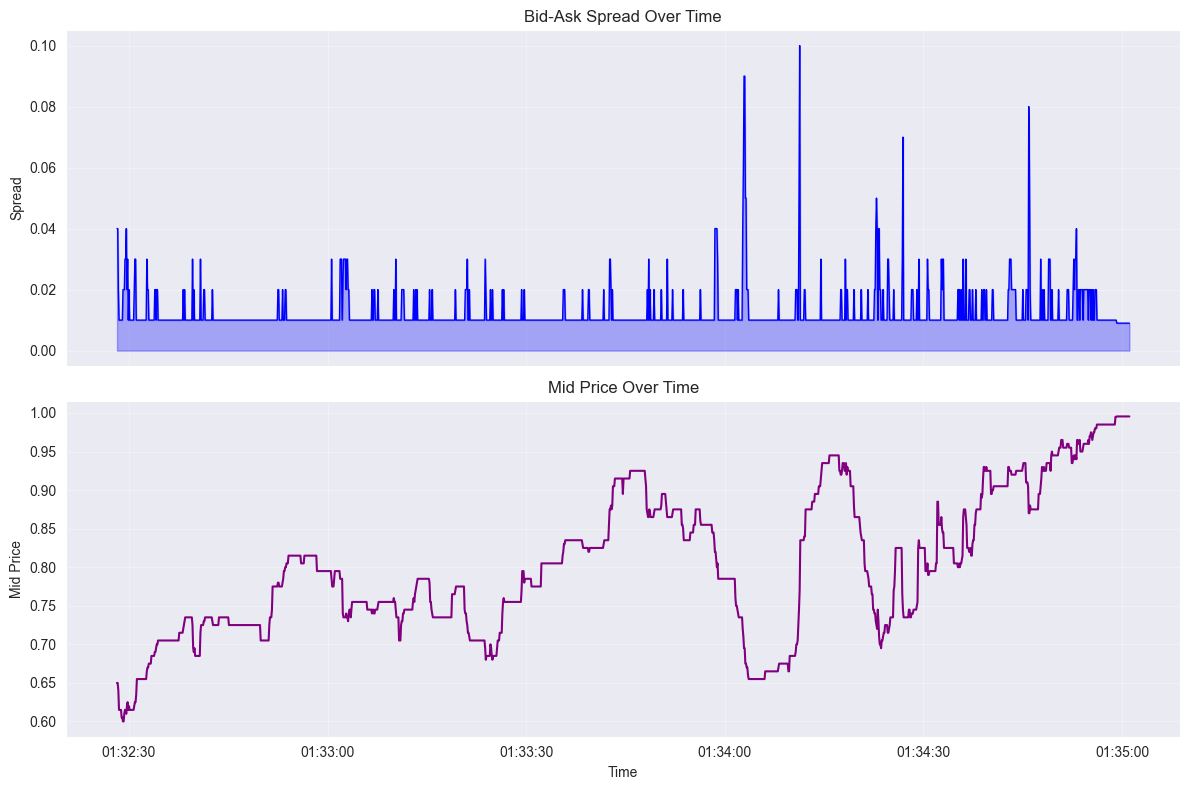


Orderbook Depth


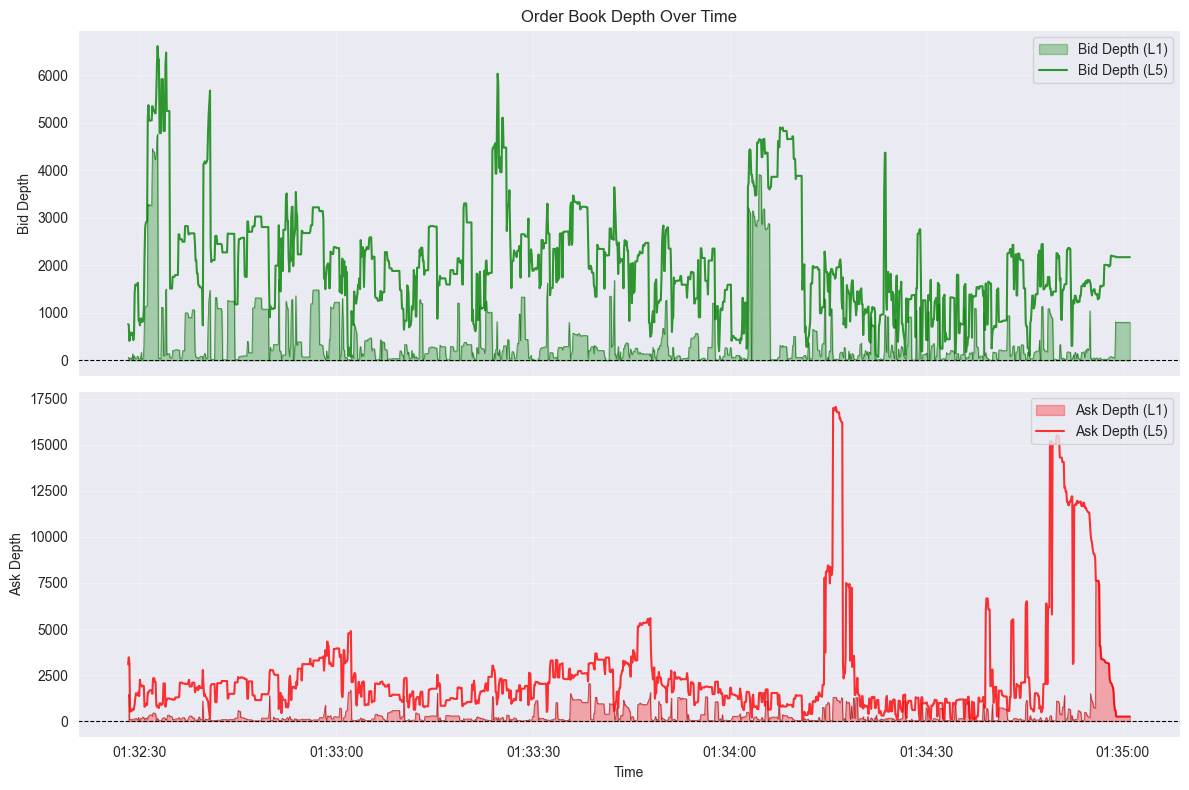


Imbalance


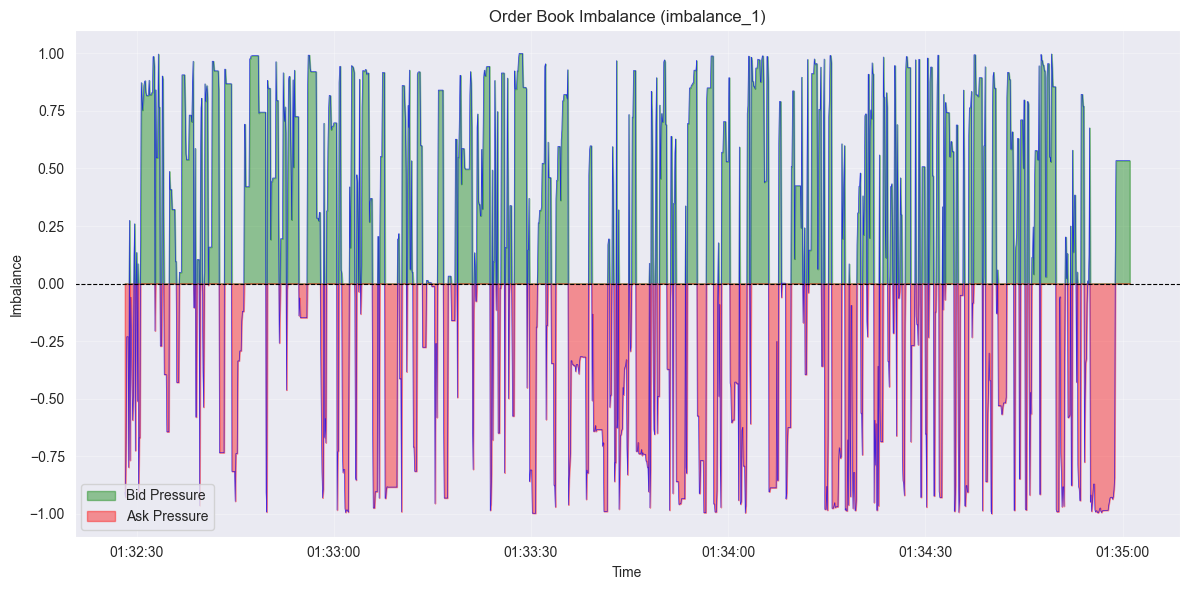


Market Timeline


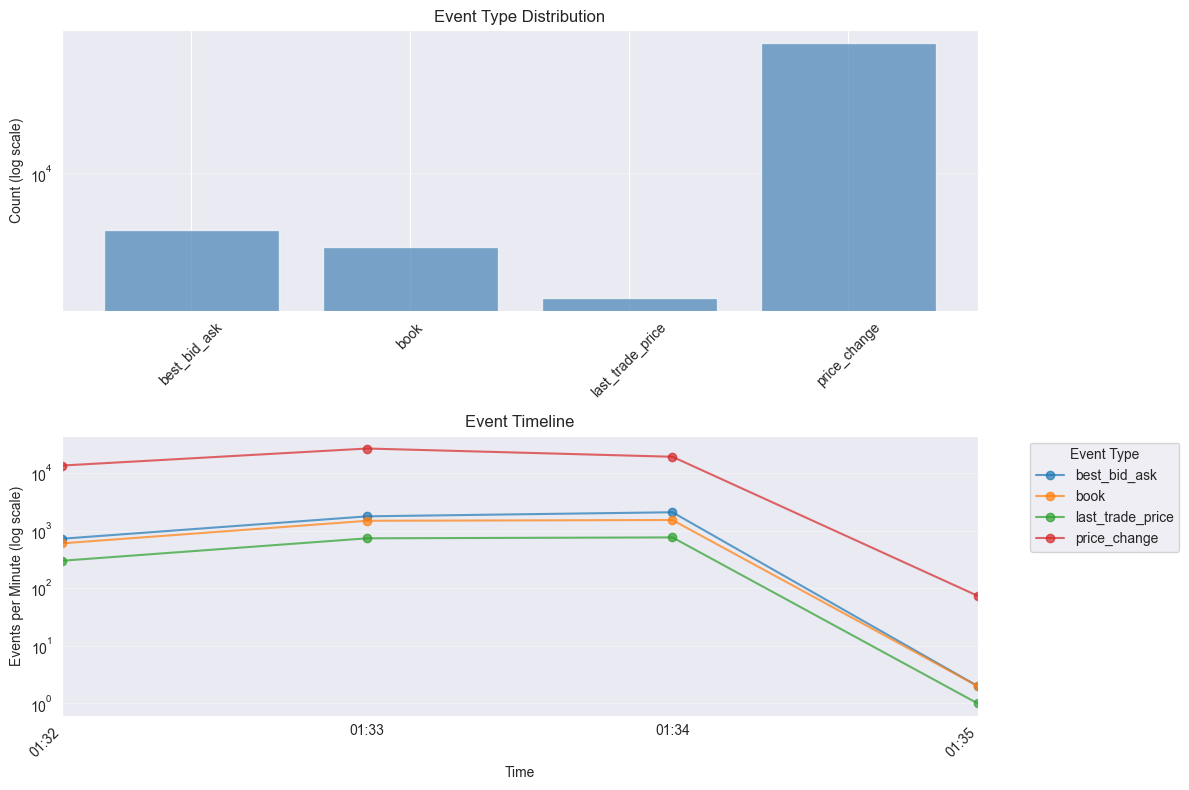

In [9]:
# Clean mode: downsample using coherent row snapshots (no column-mixing artifacts)
clean_mode = True  # Enable downsampling for clearer visualization
clean_rule = "100ms"  # Aggregate to 100ms intervals for smoother plots
event_log_scale = True
plot_features_viz = plot_features.copy()
if clean_mode and not plot_features.empty:
    tmp = plot_features.sort_index().copy()
    tmp["_bucket"] = tmp.index.floor(clean_rule)
    plot_features_viz = (
        tmp.groupby("_bucket", sort=True).tail(1).set_index("_bucket").sort_index()
    )

    # Optional regularized timeline for cleaner plotting
    full_index = pd.date_range(
        start=plot_features_viz.index.min(),
        end=plot_features_viz.index.max(),
        freq=clean_rule,
        tz=plot_features_viz.index.tz,
    )
    plot_features_viz = plot_features_viz.reindex(full_index).ffill()

print(f"Using market_id filter: {sample_market_id}")
print(f"Using token_id filter: {sample_token_id}")
if resolution_ts is not None:
    print(f"market_resolved at: {resolution_ts}")
if last_change_ts is not None:
    print(f"last feature change at: {last_change_ts}")
if cutoff_ts is not None:
    print(f"visualization cutoff: {cutoff_ts}")
print(f"Rows plotted (raw): {len(plot_features)}")
print(
    f"Rows plotted (viz): {len(plot_features_viz)} | "
    f"clean_mode={clean_mode} | rule={clean_rule}"
)
print(f"Event timeline log scale: {event_log_scale}")

figures = {
    "Spread Timeseries": plot_spread_timeseries(plot_features_viz, sample_market_id),
    "Orderbook Depth": plot_orderbook_depth(plot_features_viz, sample_market_id),
    "Imbalance": plot_imbalance(plot_features_viz, sample_market_id),
    "Market Timeline": plot_market_timeline(
        plot_market_events,
        sample_market_id,
        log_scale=event_log_scale,
    ),
}

for name, fig in figures.items():
    print(f"\n{name}")
    display(fig)
    plt.close(fig)

## Step 3: Alpha 1 - Imbalance-Based Signal

**Intuition:** When bids significantly outnumber asks (positive imbalance), it suggests buying pressure.

**Signal Rules:**
- Buy signal: imbalance_1 > 5% (bids dominate)
- Sell signal: imbalance_1 < -5% (asks dominate)  
- Neutral: -5% to +5%

In [10]:
# Create imbalance signal
print("Creating Imbalance Signal...")
print("=" * 80)

if "imbalance_1" not in features.columns:
    print("❌ imbalance_1 column not found")
else:
    # Drop rows with missing imbalance
    imbalance_df = features[features["imbalance_1"].notna()].copy()
    print(f"Valid imbalance data: {len(imbalance_df)} / {len(features)} rows")

    # Create signal
    threshold = 0.05  # 5% threshold
    imbalance_df["imbalance_signal"] = 0  # Neutral
    imbalance_df.loc[imbalance_df["imbalance_1"] > threshold, "imbalance_signal"] = 1  # Buy
    imbalance_df.loc[imbalance_df["imbalance_1"] < -threshold, "imbalance_signal"] = -1  # Sell

    # Analyze signal distribution
    signal_counts = imbalance_df["imbalance_signal"].value_counts().sort_index()
    print("\nSignal Distribution:")
    pct_sell = signal_counts.get(-1, 0) / len(imbalance_df) * 100
    print(f"  Sell (-1):   {signal_counts.get(-1, 0):6d} ({pct_sell:5.1f}%)")
    pct_neutral = signal_counts.get(0, 0) / len(imbalance_df) * 100
    print(f"  Neutral (0): {signal_counts.get(0, 0):6d} ({pct_neutral:5.1f}%)")
    pct_buy = signal_counts.get(1, 0) / len(imbalance_df) * 100
    print(f"  Buy (1):     {signal_counts.get(1, 0):6d} ({pct_buy:5.1f}%)")

Creating Imbalance Signal...
Valid imbalance data: 593950 / 594188 rows

Signal Distribution:
  Sell (-1):   286357 ( 48.2%)
  Neutral (0):  21279 (  3.6%)
  Buy (1):     286314 ( 48.2%)


In [11]:
# Analyze signal quality
print("\nSignal Quality by Direction:")
print("=" * 80)

for signal_val in [-1, 0, 1]:
    mask = imbalance_df["imbalance_signal"] == signal_val
    signal_name = ["Sell", "Neutral", "Buy"][signal_val + 1]

    if mask.any():
        avg_imbalance = imbalance_df[mask]["imbalance_1"].mean()
        avg_spread = imbalance_df[mask]["spread"].mean()
        avg_depth = imbalance_df[mask]["bid_depth_1"].mean()

        print(f"{signal_name:8s} ({mask.sum():5d} rows):")
        print(f"  avg imbalance: {avg_imbalance:8.4f}")
        print(f"  avg spread:    {avg_spread:8.6f}")
        print(f"  avg bid_depth: {avg_depth:8.2f}")
        print()


Signal Quality by Direction:
Sell     (286357 rows):
  avg imbalance:  -0.6217
  avg spread:    0.012859
  avg bid_depth:   100.02

Neutral  (21279 rows):
  avg imbalance:   0.0000
  avg spread:    0.012401
  avg bid_depth:   179.13

Buy      (286314 rows):
  avg imbalance:   0.6218
  avg spread:    0.012876
  avg bid_depth:   593.99



## Step 4: Alpha 2 - Spread-Based Signal

**Intuition:** Tight spreads indicate tight competition and lower execution cost (good for trading).
Wide spreads suggest uncertainty or lower liquidity (avoid adverse selection).

**Signal Rules:**
- Good execution (tight): spread < 50th percentile
- Poor execution (wide): spread > 75th percentile

In [12]:
# Create spread signal
print("Creating Spread Signal...")
print("=" * 80)

if "spread" not in features.columns:
    print("❌ spread column not found")
else:
    spread_df = features[["spread"]].copy()

    # Calculate percentiles
    p50 = spread_df["spread"].median()
    p75 = spread_df["spread"].quantile(0.75)

    print("Spread Percentiles:")
    print(f"  50th: {p50:.8f}")
    print(f"  75th: {p75:.8f}")

    # Create signal
    spread_df["spread_signal"] = 0  # Medium
    spread_df.loc[spread_df["spread"] < p50, "spread_signal"] = 1   # Tight (good)
    spread_df.loc[spread_df["spread"] > p75, "spread_signal"] = -1  # Wide (bad)

    # Distribution
    signal_counts = spread_df["spread_signal"].value_counts().sort_index()
    print("\nSignal Distribution:")
    pct_wide = signal_counts.get(-1, 0) / len(spread_df) * 100
    print(f"  Wide (-1):   {signal_counts.get(-1, 0):6d} ({pct_wide:5.1f}%)")
    pct_medium = signal_counts.get(0, 0) / len(spread_df) * 100
    print(f"  Medium (0):  {signal_counts.get(0, 0):6d} ({pct_medium:5.1f}%)")
    pct_tight = signal_counts.get(1, 0) / len(spread_df) * 100
    print(f"  Tight (1):   {signal_counts.get(1, 0):6d} ({pct_tight:5.1f}%)")

Creating Spread Signal...
Spread Percentiles:
  50th: 0.01000000
  75th: 0.01000000

Signal Distribution:
  Wide (-1):   110733 ( 18.6%)
  Medium (0):  390841 ( 65.8%)
  Tight (1):    92614 ( 15.6%)


## Step 6: Combine Signals

When multiple signals agree, we have higher conviction.

In [13]:
# Combine signals where we have both
print("Combining Signals...")
print("=" * 80)

combined = features.copy()

# Add the imbalance signal - recompute directly on combined to avoid index alignment issues
threshold = 0.05
combined["imbalance_signal"] = 0  # Neutral
combined.loc[combined["imbalance_1"] > threshold, "imbalance_signal"] = 1  # Buy
combined.loc[combined["imbalance_1"] < -threshold, "imbalance_signal"] = -1  # Sell

# Add the spread signal - recompute directly on combined
p50 = combined["spread"].median()
p75 = combined["spread"].quantile(0.75)
combined["spread_signal"] = 0  # Medium
combined.loc[combined["spread"] < p50, "spread_signal"] = 1   # Tight (good)
combined.loc[combined["spread"] > p75, "spread_signal"] = -1  # Wide (bad)

# Find rows where both signals agree
combined["signal_agreement"] = (
    combined["imbalance_signal"] * combined["spread_signal"]
)

agreement = combined[combined["signal_agreement"] > 0]
print("\nSignal Agreement:")
pct_agreement = len(agreement) / len(combined) * 100
print(
    f"  Both signals agree (conviction): {len(agreement)} / {len(combined)} "
    f"rows ({pct_agreement:.1f}%)"
)

# Show breakdown
agreement_counts = combined["signal_agreement"].value_counts().sort_index()
print("\nSignal Strength Distribution:")
print(f"  Strong buy (both +1):     {agreement_counts.get(1, 0):6d}")
print(f"  Mixed signals:            {agreement_counts.get(0, 0):6d}")
print(f"  Strong sell (both -1):    {agreement_counts.get(-1, 0):6d}")

Combining Signals...

Signal Agreement:
  Both signals agree (conviction): 104698 / 594188 rows (17.6%)

Signal Strength Distribution:
  Strong buy (both +1):     104698
  Mixed signals:            397585
  Strong sell (both -1):     91905


## Step 7: Market-Level Insights

Which markets show the strongest signals?

In [14]:
# Aggregate by market
print("Market-Level Signal Strength")
print("=" * 80)

if "market_id" in combined.columns and "token_id" in combined.columns:
    combined["signal_strength"] = (
        combined["imbalance_signal"].abs() + combined["spread_signal"].abs()
    ) / 2

    # Get top markets by signal strength
    top_markets = (
        combined.groupby(["market_id", "token_id"])["signal_strength"]
        .mean()
        .nlargest(10)
    )

    print("Top 10 Markets by Average Signal Strength:")
    print()
    for market_idx, strength in top_markets.items():
        market_id, token_id = market_idx  # type: ignore[misc]
        print(f"  {market_id[:30]:30s} | {token_id[:20]:20s} | strength={strength:.3f}")
else:
    print("market_id or token_id column not found")

Market-Level Signal Strength
Top 10 Markets by Average Signal Strength:

  0xee28465a91d9f853c0e79e11cbcf | 98666831037352033086 | strength=0.763
  0xc5c69dcfdd42c0eff19483287986 | 51303595383274112705 | strength=0.698
  0xf1a9546c5dc2710a7efc30c26c3b | 11425686417411891903 | strength=0.693
  0xf2741fbee4be3e1ac0349d7eb2b3 | 27280693789542114371 | strength=0.651
  0x0f50c605aaea09ba2fd4fd284009 | 63847191823143033927 | strength=0.647
  0x0f50c605aaea09ba2fd4fd284009 | 10307420505822550159 | strength=0.641
  0xee28465a91d9f853c0e79e11cbcf | 40489379628808077911 | strength=0.637
  0xf2741fbee4be3e1ac0349d7eb2b3 | 38946012607107691080 | strength=0.620
  0xc5c69dcfdd42c0eff19483287986 | 47148009703132642885 | strength=0.619
  0xf1a9546c5dc2710a7efc30c26c3b | 57504287525633207613 | strength=0.609


## Step 8: Next Steps

Now that you've seen how alphas work:

### Building New Alphas

1. **Explore features**: Look at the data, understand what moves markets
2. **Form hypothesis**: E.g., "Wide spreads lead to reversion" or "Imbalance predicts momentum"
3. **Create signal**: Simple threshold-based rules work well initially
4. **Test signal**: Check correlation with market moves, look for edges
5. **Combine**: Multi-signal approaches often work better

### Example Ideas

- **Momentum Alpha**: Imbalance increase → momentum signal
- **Reversion Alpha**: Extreme imbalance → reversion signal
- **Volatility Alpha**: Spread changes → volatility signal
- **Liquidity Alpha**: Depth changes → liquidity migration signal
- **Regime Alpha**: Combine multiple signals based on market regime

### Evaluation Tips

- Check correlation between signal and price movements
- Analyze signal quality by market
- Monitor signal stationarity over time
- Use cross-market patterns to improve signals